Check python.  We want Python 3.10 for using Hugging Face models.

##  Exploring GPT2

[OpenAI Team on Limitations and Bias.](https://huggingface.co/openai-community/gpt2)

In [1]:
import sys
#dir(sys)
sys.version_info

sys.version_info(major=3, minor=12, micro=5, releaselevel='final', serial=0)

In [2]:
! conda env list

# conda environments:
#
base                     /Users/gawron/opt/anaconda3
live_plot                /Users/gawron/opt/anaconda3/envs/live_plot
p310                     /Users/gawron/opt/anaconda3/envs/p310
p312                  *  /Users/gawron/opt/anaconda3/envs/p312
p312clone                /Users/gawron/opt/anaconda3/envs/p312clone
p312exp                  /Users/gawron/opt/anaconda3/envs/p312exp
rstudio                  /Users/gawron/opt/anaconda3/envs/rstudio
transformers             /Users/gawron/opt/anaconda3/envs/transformers



Also for using Hugging Face Models, check that we have authorization data in the environment. This
is optional but prevent ssome warning messages.

In [3]:
import os
HF_TOKEN = os.environ["HF_TOKEN"]

In [4]:
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

In [5]:
class MultiHeadAttention(nn.Module):
    """
    x_out = self.forward(x_in)
    
    x_in: batch_size x context_length x d_in 
    
    x_out: batch_size x context_length x d_out
    
    Note that an instantiated learner is indifferent to 
    the particular value of batch_size. The assumption is
    simply that the input is a 3D matrix and the first dimension is batch
    size, but only context_length, d_in, and d_out are parameters of 
    the learner.
    
    The d_out dimensions will be evenly divided among the heads, so
    d_out must be evenly divisible by num_heads. 
    """
    def __init__(self, d_in, d_out, 
                 context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert (d_out % num_heads == 0), \
            "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        # Will divide the d_out dimensions evenly among the heads
        self.head_dim = d_out // num_heads    #1
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)   
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length),
                       diagonal=1)
        )

    def forward(self, x):
        b, context_length, d_in = x.shape
        # keys is now b x context_length x d_out
        keys = self.W_key(x)         #3
        queries = self.W_query(x)    #3
        values = self.W_value(x)     #3

        # dividing d_out into num_heads components; each component has shape head_dim 
        # keys is now b x context_length x num_heads x head_dim
        keys = keys.view(b, context_length, self.num_heads, self.head_dim)       #4
        values = values.view(b, context_length, self.num_heads, self.head_dim)  
        queries = queries.view(                                             
            b, context_length, self.num_heads, self.head_dim                    
        )                                                                   


        # keys becomes b x num_heads x context_length x head_dim
        keys = keys.transpose(1, 2)          #5
        queries = queries.transpose(1, 2)    #5
        values = values.transpose(1, 2)      #5

        # make keys compatible for matrix multiplication 
        #   mapping     @  mapped
        #   (..., m, n) @ (..., n, m)
        # keys becomes b x num_heads x head_dim X context_length
        # attn_scores will be b x num_heads x context_length x context_length
        attn_scores = queries @ keys.transpose(2, 3)   #6
        mask_bool = self.mask.bool()[:context_length, :context_length]    #7

        attn_scores.masked_fill_(mask_bool, -torch.inf)     #8

        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)
        
        # attn_weights : b x num_heads x context_length x context_length
        # values :  b x num_heads x context_length x head_dim
        # context_vec:  b x num_heads x context_length x head_dim
        # transpose(1, 2) =>
        # context_vec:  b x context_length x num_heads x head_dim
        context_vec = (attn_weights @ values).transpose(1, 2)   #9
        # Recombine num_heads x head_dim into d_out
        # context_vec:  b x context_length x d_out
        context_vec = context_vec.contiguous().view(
            b, context_length, self.d_out
        )                                           #10
        # And one more linear map for good luck to produce what we might call logits;
        # 2D map is a square matrix:
        # context_vec:  b x context_length x d_out
        context_vec = self.out_proj(context_vec)    #11
        return context_vec       

class LayerNorm(nn.Module):
    """
    
    """
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) * 
            (x + 0.044715 * torch.pow(x, 3))
        ))

# We wrap it in a feed forward layer
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)
    
class TransformerBlock(nn.Module):
    """
    Required input argument is a GPT 
    conifiguration dictionary (GPT_CONFIG_124M in this NB).
    """
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"], 
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        shortcut = x  #1
        x = self.norm1(x)
        x = self.att(x)
        x = self.drop_shortcut(x)
        x = x + shortcut      #2

        shortcut = x         #3
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut      #4
        return x
#1 Shortcut connection for attention block
#2 Add the original input back
#3 Shortcut connection for feed forward block
#4 Adds the original input back

class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.config = cfg
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )
        
    
    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
 #1
        pos_embeds = self.pos_emb(
            torch.arange(seq_len, device=in_idx.device)
        )
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

In [6]:
from importlib.metadata import version
import torch

print("torch version:", version("torch"))


#from previous_chapters import GPTModel
# If the `previous_chapters.py` file is not available locally,
# you can import it from the `llms-from-scratch` PyPI package.
# For details, see: https://github.com/rasbt/LLMs-from-scratch/tree/main/pkg
# E.g.,
# from llms_from_scratch.ch04 import GPTModel

GPT_CONFIG_124M = {
    "vocab_size": 50257,   # Vocabulary size
    "context_length": 256, # Shortened context length (orig: 1024)
    "emb_dim": 768,        # Embedding dimension
    "n_heads": 12,         # Number of attention heads
    "n_layers": 12,        # Number of layers
    "drop_rate": 0.1,      # Dropout rate
    "qkv_bias": False      # Query-key-value bias
}

gpt = GPT_CONFIG_124M

#1 The device setting will allow us to train 
#  the model on a CPU or GPU, depending on which device the input data sits on.
# Currently on my Mac, to get a qualifying torch version O need to use my transformers
# environment

def choose_device():
    if torch.cuda.is_available():
        device = torch.device("cuda")
    elif torch.backends.mps.is_available():
        # Use PyTorch 2.9 or newer for stable mps results
        major, minor = map(int, torch.__version__.split(".")[:2])
        if (major, minor) >= (2, 9):
            device = torch.device("mps")
        else:
            device = torch.device("cpu")
    else:
        device = torch.device("cpu")
    return device

device=choose_device()
print("Device:", device)

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval();  # Disable dropout during inference

torch version: 2.5.1
Device: cpu


Execute this next cell at your own risk.  It overrules the conservative device choice made in the cell above.

On a Mac (per Raschke) the mps may not be numerically stable with
vcertain versions of `torch` (see below).

#### Plotting code

In [7]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import numpy as np

def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, (ax1,ax3) = plt.subplots(2, 1, figsize=(5, 7))
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(
        epochs_seen, val_losses, linestyle="-.", label="Validation loss"
    )
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax2 = ax1.twiny()                   #1
    ax2.plot(tokens_seen, train_losses, alpha=0)     #2
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    idx = np.array(val_losses).argmin()
    (x,y) = epochs_seen[idx], val_losses[idx]
    ax3.annotate("min",(x,y),xytext=(-8,6),textcoords="offset points" )
    ax3.scatter([x],[y],c="firebrick",s=10)
    ax3.plot(epochs_seen, val_losses, linestyle="-", label="Validation loss closeup",
            c="aqua")
    ax3.set_xlabel("Epochs")
    ax3.set_ylabel("Loss")
    ax3.legend(loc="upper right")
    #ax3.
    plt.show()

### Generation example

In [8]:
import tiktoken

#Listing 4.8 A function for the GPT model to generate text
# Note this function is redefined with the training code
def generate_text_simple(model, idx,                 #1
                         max_new_tokens, context_size): 
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]    #2
        #idx_cond.to(device)
        #model.to(device)
        with torch.no_grad():
            logits = model(idx_cond)
        # batch x n_token x vocab_size) => batch x vocab_size
        logits = logits[:, -1, :]                    #3
        # scores => weights, shape unchanged
        probas = torch.softmax(logits, dim=-1)           #4
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)    #5
        idx = torch.cat((idx, idx_next), dim=1)     #6

    return idx

#1 idx is a (batch, n_tokens) array of indices in the current context.
#2 Crops current context if it exceeds the supported context size, 
   #e.g., if LLM supports only 5 tokens, and the idx context size is 10, 
   # then only the last 5 tokens are used as context
#3 Focuses only on the last time step, so that (batch, n_token, vocab_size) 
   # becomes (batch, vocab_size)
#4 probas has shape (batch, vocab_size).
#5 idx_next has shape (batch, 1).
#6 Appends sampled index to the running sequence, where idx has shape (batch, n_tokens+1)

def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):

    # For-loop is the same as before: Get logits, and only focus on last time step
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]

        # New: Filter logits with top_k sampling
        if top_k is not None:
            # Keep only top_k values
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(logits < min_val, torch.tensor(float("-inf")).to(logits.device), logits)

        # New: Apply temperature scaling
        if temperature > 0.0:
            logits = logits / temperature

            # New (not in book): numerical stability tip to get equivalent results on mps device
            # subtract rowwise max before softmax
            logits = logits - logits.max(dim=-1, keepdim=True).values

            # Apply softmax to get probabilities
            probs = torch.softmax(logits, dim=-1)  # (batch_size, context_len)

            # Sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1)  # (batch_size, 1)

        # Otherwise same as before: get idx of the vocab entry with the highest logits value
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)  # (batch_size, 1)

        if idx_next == eos_id:  # Stop generating early if end-of-sequence token is encountered and eos_id is specified
            break

        # Same as before: append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch_size, num_tokens+1)

    return idx

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text)
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)  # add batch dimension
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0)  # remove batch dimension
    return tokenizer.decode(flat.tolist())

In [10]:
start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you rentingetic wasnم refres RexMeCHicular stren


## Loss

In [ ]:
torch.manual_seed(123)
model = GPTModel(gpt)

## context size is 3
input_texts = ["every effort moves", "I really like"]
inputs = torch.cat([text_to_token_ids(txt, tokenizer) for txt in input_texts])
print(inputs)

# Matching these inputs, the targets contain the token IDs we want the model to 
# predict
target_texts = [" effort moves you", " really like chocolate"]
targets = torch.cat([text_to_token_ids(txt, tokenizer) for txt in target_texts])
print(targets)

with torch.no_grad():     #1
    logits = model(inputs)
# Probs for predicting targets
probas = torch.softmax(logits, dim=-1)     #2
print(probas.shape)

1. Disable gradient tracking since this is not training code.
2. Probability of each token in vocabulary

In [ ]:
token_ids = torch.argmax(probas, dim=-1, keepdim=True)
print("Token IDs:\n", token_ids)

```python
Token IDs:
 tensor([[[  682],    # First batch
         [ 2463],
         [35303]],

        [[ 8615],     #Second batch
         [23248],
         [34798]]])
```

In [ ]:
print(f"Targets batch 0: {token_ids_to_text(targets[0], tokenizer)}")
print(f"Outputs batch 0:"
      f" {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

In [ ]:
print(f"Targets batch 1: {token_ids_to_text(targets[1], tokenizer)}")
print(f"Outputs batch 1:"
      f" {token_ids_to_text(token_ids[1].flatten(), tokenizer)}")

### Computing the probabilities of the targets per the model

Get the probabilities assigned to each target word (the desired predictions)

In [ ]:
def get_target_probs (probas, targets, text_idx, verbose=False):
    vocab_idxs = targets[text_idx]
    if verbose:
        #"batch size x context size x vocab size"
        print(f"Text {text_idx}: {probas.shape} => Torch.Size[{len(vocab_idxs)}]")
    context_position_idxs = list(range(len(vocab_idxs)))
    # Shape is (len(vocab_idxs), )
    return probas[text_idx, context_position_idxs, vocab_idxs]

text_idx = 0
target_probas_1 = get_target_probs (probas, targets, text_idx,verbose=True)
print(target_probas_1)

text_idx = 1
target_probas_2 = get_target_probs (probas, targets, text_idx)
target_probas_2

### The loss function

By convention,the loss function is something we minimize, so we use **negative log probability**.  This is called the **cross entropy**.

In [ ]:
log_probas = torch.log(torch.cat((target_probas_1, target_probas_2)))
neg_avg_log_probas = torch.mean(log_probas) * -1
print(neg_avg_log_probas)

It can be computed in one step from the logits and targets:

In [ ]:
logits_flat = logits.flatten(0, 1)
targets_flat = targets.flatten()
loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
print(f"Cross entropy: {loss:.4f}")

As we learned in the Information Theory Lecture,  if we write the cross-entropy as CE, perplexity is $2^{\text{CE}}$. We'll just use $e$ as the base here:

In [ ]:
print(f"Perplexity: {torch.exp2(loss):.4f}")

## Use the Wharton story data (toy example)

In [11]:
import os
import requests

file_path = "the-verdict.txt"
url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch02/01_main-chapter-code/the-verdict.txt"

if not os.path.exists(file_path):
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    text_data = response.text
    with open(file_path, "w", encoding="utf-8") as file:
        file.write(text_data)
else:
    with open(file_path, "r", encoding="utf-8") as file:
        text_data = file.read()

In [12]:
total_characters = len(text_data)
print("Characters:", total_characters)

Characters: 20479


In [13]:
# Split train and test
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
wharton_train_data = text_data[:split_idx]
wharton_val_data = text_data[split_idx:]

In [14]:
#from chapter02 import create_dataloader_v1
from torch.utils.data import Dataset, DataLoader
import tiktoken

class GPTDatasetV1(Dataset):
    
    def __init__(self, txt, tokenizer, max_length, stride):
        """
        {input} and {target} are word sequences of the same length,
        identical except that they are offset by 1 words.  For example:
        
        input: saw the cat on the mat
        target: the cat on the mat today
        
        The idea is that as we scan the input word by word we will
        try to predict the target in parallel.   We call
        the length of input and target {max_length} (because
        at the end of document the length of {input} may be less
        than {max_length}).
        
        Initialize a dataset with datasource `txt`.  `self.input_ids`
        contains the dataset  tokenized  {token_ids} and chunked
        into {max_length} sized chunks, with the starting positions
        of the chunks {stride} apart; {self.target_ids} contains
        a copy of each chunk offset by 1.  If stride is 1, the ith chunk 
        of {input_ids} contains token_ids[i:i+max_length]
        and the ith chunk of target_ids contains token_ids[i+1:i+max_length+1]
        
        This creates a corpus suitable for the supervised learning
        of a sequence to sequence mapping.  Self.input_ids
        contains the input sequence; and due to the
        the offsetof 1, the target consumes 1 more word from the data.
        So what the learner is going to learner is how to predict the next 
        word based on a history of size {max_length}.
        """
        self.input_ids = []
        self.target_ids = []
        self.tokenizer = tokenizer

        token_ids = self.tokenizer.encode(txt)    #1

        for i in range(0, len(token_ids) - max_length, stride):     #2
            input_chunk = token_ids[i:i + max_length]
            target_chunk = token_ids[i + 1: i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):    #3
        return len(self.input_ids)

    def __getitem__(self, idx):         #4
        return self.input_ids[idx], self.target_ids[idx]

def create_dataloader_v1(txt, batch_size=4, max_length=256,
                         stride=128, shuffle=True, drop_last=True,
                         num_workers=0,
                         make_local_vocab=False):
    tokenizer = tiktoken.get_encoding("gpt2")   #1
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)   #2
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,     #3
        num_workers=num_workers     #4
    )

    return dataloader

torch.manual_seed(123)

In [15]:


# NB Training & validation data comes from the Wharton story.
wharton_train_loader = create_dataloader_v1(
    wharton_train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)
wharton_val_loader = create_dataloader_v1(
    wharton_val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

##  Use the wikitext data

```python
from datasets import load_dataset
import os

HF_TOKEN = os.environ["HF_TOKEN"]
train = load_dataset("wikitext", "wikitext-2-raw-v1", split="train",token=HF_TOKEN)
train.info.splits['train'].num_bytes
```

returns

```
11061717
```

That's bytes. So, in the neighborhood of 2 million words.

In [25]:
from datasets import load_from_disk
#wiki_2_data = load_from_disk("wikitext-2-raw-v1-all",keep_in_memory=True)
wiki_2_data = load_from_disk("wikitext-2-raw-v1-all")

In [26]:
wiki_2_train= wiki_2_data["train"]#.to_iterable_dataset()
wiki_2_val = wiki_2_data["validation"]#.to_iterable_dataset()
#train_data = wiki_2_train
#val_data = wiki_2_val

In [27]:
len(wiki_2_train)

36718

In [28]:
len(wiki_2_val)

3760

Indexing the data.  Column is "text".  Row is an integer index.  Rows vary quite a bit in length.

In [39]:
wiki_2_train["text"][70]

' The soldiers would be allowed to march away as men leaving under orders , not as conquered and surrendering soldiers . \n'

In [40]:
wiki_2_train[70]["text"]

' The soldiers would be allowed to march away as men leaving under orders , not as conquered and surrendering soldiers . \n'

In [41]:
wiki_2_train[20:400]["text"][50]

' The soldiers would be allowed to march away as men leaving under orders , not as conquered and surrendering soldiers . \n'

In [42]:
#KeyError 
#wiki_2_train[20:400][50]["text"]

This is 1-column data"

In [43]:
wiki_2_train[36716]

{'text': ' Common starlings are trapped for food in some Mediterranean countries . The meat is tough and of low quality , so it is casseroled or made into pâté . One recipe said it should be stewed " until tender , however long that may be " . Even when correctly prepared , it may still be seen as an acquired taste . \n'}

Create a sample.

In [44]:
sample = ''.join([wiki_2_train[i]['text'] for i in range(500)])

To find the number of tokens in the sample, you must tokenize it.

In [45]:
sample_toks = tokenizer.encode(sample)

In [46]:
len(sample_toks)

26037

In [29]:
#from chapter02 import create_dataloader_v1
from torch.utils.data import Dataset, DataLoader

class GPTDatasetV5(Dataset):
    
    # This is a str length (not a number of tokens)
    # So if max_length is 1024, e.g., we want
    # ths to be at least 6 times as much bcz
    # max_length counts tokens
    max_buffer_size = 2**14
    
    def __init__(self, ds, tokenizer, max_length, stride):
        self.ds_ = iter(ds.to_iterable_dataset())
        self.input_ids = []
        self.target_ids = []
        self.tokenizer = tokenizer
        txt = self.collect_text_()

        # txt is an untokenized str
        while len(txt)> 0:
            token_ids = self.tokenizer.encode(txt)    #1

            for i in range(0, len(token_ids) - max_length, stride):     #2
                input_chunk = token_ids[i:i + max_length]
                target_chunk = token_ids[i + 1: i + max_length + 1]
                self.input_ids.append(torch.tensor(input_chunk))
                self.target_ids.append(torch.tensor(target_chunk))
    
            txt = self.collect_text_()

    def __len__(self):    #3
        return len(self.input_ids)

    def __getitem__(self, idx):         #4
        return self.input_ids[idx], self.target_ids[idx]
    
    def collect_text_ (self):
        texts = []
        buffer_size = 0
        while buffer_size < self.max_buffer_size:
            try:
                txt = next(self.ds_)["text"]
            except StopIteration:
                break
            buffer_size += len(txt)
            texts.append(txt)
        return " ".join(texts)
        
        

def create_dataloader_v5(ds, batch_size=4, max_length=256,
                         stride=128, shuffle=True, drop_last=True,
                         num_workers=0,
                         make_local_vocab=False):
    tokenizer = tiktoken.get_encoding("gpt2")   #1
    dataset = GPTDatasetV5(ds, tokenizer, max_length, stride)   #2
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,     #3
        num_workers=num_workers     #4
    )

    return dataloader

torch.manual_seed(123)

Note the larger batch size.

The batch_size 2 seems to generate noisy updates  (though loss noisiness could also be due to data variation)
Setting `batch size` to 5  puts more load on memory. But on my machine,
the noisiness of both training and validation losses settled down quite a bit.


In [30]:

#batch_size=2
batch_size=5
# NB Our training & validation data comes from the wiki
wiki_2_train_loader = create_dataloader_v5(
    wiki_2_train,
    batch_size=5,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)
wiki_2_val_loader = create_dataloader_v5(
    wiki_2_val,
    batch_size=5,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

In [31]:
sample_point= 23
res = []
for (i,(x, y)) in enumerate(wiki_2_train_loader):
    print(x.shape, y.shape)
    if i == 5:
        res.append((x,y))
    if i == 6:
        break


torch.Size([5, 256]) torch.Size([5, 256])
torch.Size([5, 256]) torch.Size([5, 256])
torch.Size([5, 256]) torch.Size([5, 256])
torch.Size([5, 256]) torch.Size([5, 256])
torch.Size([5, 256]) torch.Size([5, 256])
torch.Size([5, 256]) torch.Size([5, 256])
torch.Size([5, 256]) torch.Size([5, 256])


In [32]:
#Sanity check
print("Train loader:")
for (i,(x, y)) in enumerate(wiki_2_train_loader):
    print(x.shape, y.shape)
    if i == 6:
        break

print("\nValidation loader:")
for (i,(x, y)) in enumerate(wiki_2_val_loader):
    print(x.shape, y.shape)
    if i == 6:
        break

Train loader:
torch.Size([5, 256]) torch.Size([5, 256])
torch.Size([5, 256]) torch.Size([5, 256])
torch.Size([5, 256]) torch.Size([5, 256])
torch.Size([5, 256]) torch.Size([5, 256])
torch.Size([5, 256]) torch.Size([5, 256])
torch.Size([5, 256]) torch.Size([5, 256])
torch.Size([5, 256]) torch.Size([5, 256])

Validation loader:
torch.Size([5, 256]) torch.Size([5, 256])
torch.Size([5, 256]) torch.Size([5, 256])
torch.Size([5, 256]) torch.Size([5, 256])
torch.Size([5, 256]) torch.Size([5, 256])
torch.Size([5, 256]) torch.Size([5, 256])
torch.Size([5, 256]) torch.Size([5, 256])
torch.Size([5, 256]) torch.Size([5, 256])


##  Training code

In [16]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)        
    target_batch = target_batch.to(device)      
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(
        logits.flatten(0, 1), target_batch.flatten()
    )
    return loss

#1 Iterates over all batches if no fixed num_batches is specified
#2 Reduces the number of batches to match the total number of batches in the 
   # data loader if num_batches exceeds the number of batches in the data loader
#3 Sums loss for each batch
#4 Averages the loss over all batches

def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)     #1
    else:
        num_batches = min(num_batches, len(data_loader))   #2
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            total_loss += loss.item()    #3
        else:
            break
    return total_loss / num_batches    #4

Take it out for a spin.

In [71]:
with torch.no_grad():                                        #2
    train_loss = calc_loss_loader(wiki_2_train_loader, model, device,num_batches=1)    #3
    val_loss = calc_loss_loader(wiki_2_val_loader, model, device,num_batches=1)
print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 10.987802505493164
Validation loss: 10.998900413513184


The workhorse functions.

In [17]:
import math

"""
With this version we had a bad overshoot (due to the LR being set too high):

Ep 6 (Step 009400): Train loss 3.616, Val loss 5.340
Ep 6 (Step 009425): Train loss 3.634, Val loss 5.334
Ep 6 (Step 009450): Train loss 3.651, Val loss 5.340
Ep 6 (Step 009475): Train loss 8.317, Val loss 8.307
Ep 6 (Step 009500): Train loss 8.057, Val loss 8.118
Ep 6 (Step 009525): Train loss 7.927, Val loss 7.855

This took epochs to recover from.
"""

def train_model_simple(model, train_loader, val_loader,
                       optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    #1 Initializes lists to track losses and tokens seen
    train_losses, val_losses, track_tokens_seen = [], [], []   
    tokens_seen, global_step = 0, -1
    #2 Starts the main training loop
    for epoch in range(num_epochs):    
        model.train()
        for input_batch, target_batch in train_loader:
            #3 Resets loss gradients from the previous batch iteration
            optimizer.zero_grad()   
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            #4 Calculates loss gradients
            loss.backward()      
            #5 Updates model weights using loss gradients
            #  Also tweaks the learning rate as learning progresses
            optimizer.step()                    
            tokens_seen += input_batch.numel()
            global_step += 1
            #6 Optional evaluation step
            if global_step % eval_freq == 0:   
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, "
                      f"Val loss {val_loss:.3f}"
                )
        #7 Prints a sample text after each epoch
        generate_and_print_sample(                   
            model, tokenizer, device, start_context
        )
    return train_losses, val_losses, track_tokens_seen

ORIG_BOOK_VERSION = False

# The training code from appendix D
# which implements learning rate warmup, cosine decay, and gradient clipping
def train_model(model, train_loader, val_loader, optimizer, device,
                n_epochs, eval_freq, eval_iter, start_context, tokenizer,
                warmup_steps, initial_lr=3e-05, min_lr=1e-6):

    train_losses, val_losses, track_tokens_seen, track_lrs = [], [], [], []
    tokens_seen, global_step = 0, -1

    # Retrieve the maximum learning rate from the optimizer
    peak_lr = optimizer.param_groups[0]["lr"]

    # Calculate the total number of iterations in the training process
    total_training_steps = len(train_loader) * n_epochs

    # Calculate the learning rate increment during the warmup phase
    lr_increment = (peak_lr - initial_lr) / warmup_steps

    for epoch in range(n_epochs):
        model.train()
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            global_step += 1

            # Adjust the learning rate based on the current phase (warmup or cosine annealing)
            if global_step < warmup_steps:
                # Linear warmup
                lr = initial_lr + global_step * lr_increment  
            else:
                # Cosine annealing after warmup
                progress = ((global_step - warmup_steps) / 
                            (total_training_steps - warmup_steps))
                lr = min_lr + (peak_lr - min_lr) * 0.5 * (1 + math.cos(math.pi * progress))

            # Apply the calculated learning rate to the optimizer
            for param_group in optimizer.param_groups:
                param_group["lr"] = lr
            track_lrs.append(lr)  # Store the current learning rate

            # Calculate and backpropagate the loss
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()

            # Apply gradient clipping after the warmup phase to avoid exploding gradients
            if ORIG_BOOK_VERSION:
                if global_step > warmup_steps:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  
            else:
                # the book originally used global_step > warmup_steps, which led to a skipped clipping 
                # step after warmup
                if global_step >= warmup_steps:  
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                
            optimizer.step()
            tokens_seen += input_batch.numel()

            # Periodically evaluate the model on the training and validation sets
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader,
                    device, eval_iter
                )
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                # Print the current losses
                print(f"Ep {epoch+1} (Iter {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, "
                      f"Val loss {val_loss:.3f}"
                )

        # Generate and print a sample from the model to monitor progress
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )

    return train_losses, val_losses, track_tokens_seen, track_lrs

def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    #1 Dropout is disabled during evaluation for stable, reproducible results.
    model.eval()
    #2 Disables gradient tracking, which is not required during evaluation, 
    #  to reduce the computational overhead
    with torch.no_grad():                  
        train_loss = calc_loss_loader(
            train_loader, model, device, num_batches=eval_iter
        )
        val_loss = calc_loss_loader(
            val_loader, model, device, num_batches=eval_iter
        )
    model.train()
    return train_loss, val_loss

def generate_and_print_sample(model, tokenizer, device, start_context):
    #1 Compact print format
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    sample_ids_len = len(encoded[0])
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))      #1
    model.train()
    
#Listing 4.8 A function for the GPT model to generate text
def generate_text_simple(model, idx,                 #1
                         max_new_tokens, context_size): 
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]    #2
        with torch.no_grad():
            logits = model(idx_cond)
        # batch x n_token x vocab_size) => batch x vocab_size
        logits = logits[:, -1, :]                    #3
        # scores => weights, shape unchanged
        probas = torch.softmax(logits, dim=-1)           #4
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)    #5
        idx = torch.cat((idx, idx_next), dim=1)     #6

    return idx

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)    #1
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0)                #2
    return tokenizer.decode(flat.tolist())


# Run training

In [18]:
import tiktoken
import time

def run_training (train_loader,val_loader,n_epochs,
                  eval_freq=5, eval_iter=1, print_timing=True):
  
    model, optimizer = initialize_model_and_optimizer (GPT_CONFIG_124M)
    tokenizer = tiktoken.get_encoding("gpt2")

    #####  For warmup  #####################################
    total_steps = len(train_loader) * n_epochs
    warmup_steps = int(0.2 * total_steps) # 20% warmup
    ########################################################

    # Note:
    # Uncomment the following code to calculate the execution time

    start_time = time.time()

    #peak_lr = 0.001  # this was originally set to 5e-4 in the book by mistake
    #optimizer = torch.optim.AdamW(model.parameters(), 
    #                              lr=peak_lr, weight_decay=0.1) 
  
    train_losses, val_losses, tokens_seen, lrs = train_model(
        model, train_loader, val_loader, optimizer, device, n_epochs=n_epochs,
        eval_freq=eval_freq, eval_iter=eval_iter, start_context="Every effort moves you",
        tokenizer=tokenizer, warmup_steps=warmup_steps, 
        initial_lr=1e-5, min_lr=1e-5
    )

    end_time = time.time()
    execution_time_minutes = (end_time - start_time) / 60
    if print_timing:
        print(f"Training completed in {execution_time_minutes:.2f} minutes.")
    train_results = dict(train_losses=train_losses,
                        val_losses=val_losses,
                        tokens_seen = tokens_seen,
                        lrs=lrs,
                        execution_time=execution_time_minutes)
    return model,train_results

def initialize_model_and_optimizer (gpt_config,seed=123):
    torch.manual_seed(seed)
    model = GPTModel(gpt_config)
    model.to(device)

    peak_lr = 0.001  # this was originally set to 5e-4 in the book by mistake
    optimizer = torch.optim.AdamW(model.parameters(), 
                                  lr=peak_lr, weight_decay=0.1)
    return model, optimizer

In [20]:

device = choose_device()

#Using train loader and val loader for wharton data

# ona mac: Overruling the above function (use at your own risk)
#Train loss 0.084, Val loss 6.860
#Training completed in 1.69 minutes.
device = torch.device("mps")
print("Device:", device)
n_epochs=20
model,train_results = run_training (wharton_train_loader,wharton_val_loader,n_epochs=n_epochs)

Device: mps
Ep 1 (Iter 000000): Train loss 10.969, Val loss 10.938
Ep 1 (Iter 000005): Train loss 9.483, Val loss 9.611
Every effort moves you,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Ep 2 (Iter 000010): Train loss 8.192, Val loss 8.527
Ep 2 (Iter 000015): Train loss 6.784, Val loss 7.261
Every effort moves you, the                                                
Ep 3 (Iter 000020): Train loss 6.234, Val loss 6.617
Ep 3 (Iter 000025): Train loss 5.413, Val loss 7.103
Every effort moves you the the the the the the the the the the the the the the the the the the the the the the the the. ". ". " the the the the the the. ", the the the. ".
Ep 4 (Iter 000030): Train loss 5.987, Val loss 7.016
Ep 4 (Iter 000035): Train loss 5.338, Val loss 6.667
Every effort moves you, and, and, and, and, and, and a, and, and, and, and, and, and, and, and the picture, and, and, and, and, and, and, and, and, and,
Ep 5 (Iter 000040): Train loss 4.582, Val loss 6.525
Every effort moves you know the pic

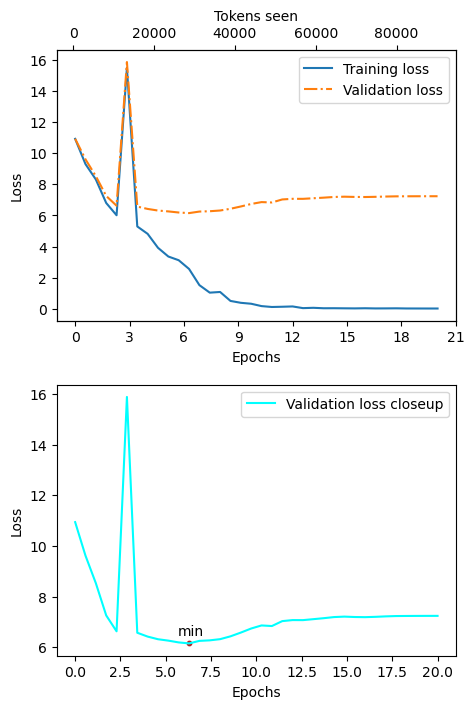

In [30]:
epochs_tensor = torch.linspace(0, n_epochs, len(train_results["train_losses"]))
plot_losses(epochs_tensor, train_results["tokens_seen"], train_results["train_losses"], 
            train_results ["val_losses"])

##  The LLM as a compression engine

This is an overtrained model.  As a result, it has memorized considerable amounts of its training data.

We domonstrate by presenting the model with a prompt taken from the training.  What it does is
spit out the rest of the relevant passage:

In [133]:
def find_best_match (token_ids,train_loader):
    max_score = 0
    best = (0,0,[])
    token_set = set(token_ids.tolist())
    #print("ts", len(token_set))
    for (i,batch) in enumerate(train_loader):
        #print("batch", len(batch))
        for (j,seq) in enumerate(batch[0]):
            #print("seq", seq.shape)
            #if i==5:
            #    #print(seq)
            #    #print(token_set)
            score = score_seq (seq.tolist(),token_set)
            if score > max_score:
                max_score = score
                best = (i,j,seq)
    subseq = find_best_subseq(best[2].tolist(),token_ids)
    if subseq is not None:
        return subseq,best
    else:
        return [],best

def score_seq (seq,token_set):
    return len(token_set.intersection(seq))

def find_best_subseq(seq,token_ids,min_match_len=4):
    """
    Having found the context that has the best match 
    with the prompt, we go on to extract the best 
    matching subsequence of that context.
    """
    global extending
    match_len = len(token_ids)
    extending = []
    while len(extending) == 0 and len(token_ids) >= min_match_len:
        for (i,idx) in enumerate(seq):
            for curr in extending:
                if len(curr) < match_len and idx == token_ids[len(curr)]:
                    curr.append(idx)
            if idx == token_ids[0]:
                extending.append([idx])
        token_ids=token_ids[1:]
    # Return the longest matching subsequence
    extending.sort(key=len)
    if extending:
        return extending[-1]

In [99]:
sample_start = """open countenance. "It's his ridiculous modesty"""
context_size = model.pos_emb.weight.shape[0]
continuation_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )[0]

In [141]:
print("\n .... prompt ... \n",f"{'='*17}")
print(sample_start)
print("\n .... model generated continuation ... \n",f"{'='*37}")
text = token_ids_to_text(continuation_ids, tokenizer).strip()
print(text)
print("\n ... best match from training ... \n",f"{'='*33}")
match_ids, (batch_no, part, context) = find_best_match (continuation_ids,train_loader)
print(token_ids_to_text(torch.tensor([match_ids]), tokenizer))


 .... prompt ... 
open countenance. "It's his ridiculous modesty

 .... model generated continuation ... 
open countenance. "It's his ridiculous modesty, you know. He says they're not fit to have about; he's sent them all away to see the end; and I had been at the donkey--the his pictures--and it was--that was his own trade he was a little the end-chair I was.

 ... best match from training ... 
 countenance. "It's his ridiculous modesty, you know. He says they're not fit to have about; he's sent them all away to see the


In [ ]:
n_epochs=20

In [ ]:
epochs_tensor = torch.linspace(0, n_epochs, len(train_losses))
plot_losses(epochs_tensor, train_results['tokens_seen'], train_results['train_losses'], 
            train_results['val_losses'])

In [165]:
import tiktoken
import torch

torch.manual_seed(123)

#tokenizer = tiktoken.get_encoding("gpt2")

text="fitting that they should mourn him. Among his own sex fewer regrets were heard"

token_ids = generate(
    model=model.to(device),
    idx=text_to_token_ids(text, tokenizer).to(device),
    max_new_tokens=30,
    context_size=model.config["context_length"],
    top_k=25,
    temperature=.4
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 fitting that they should mourn him. Among his own sex fewer regrets were heard .  =
    =  The of – =@  =@ in the @ " .       


###  Train on the larger training set

In [45]:
#Using train loader and val loader for wharton data
#eval_freq=5, eval_iter=1, 
# Using mps
#
use_mps = True
if use_mps and torch.backends.mps.is_available():
    # 10 epochs completed in 410.86 minutes.
    # Nearly 7 hours!
    # Train loss 0.864, Val loss 5.855
    device = torch.device("mps")
model,train_results = run_training (wiki_2_train_loader,wiki_2_val_loader,
                                    eval_freq=10, eval_iter=10, 
                                    n_epochs=10)

Ep 1 (Iter 000000): Train loss 10.936, Val loss 10.939
Ep 1 (Iter 000010): Train loss 10.348, Val loss 10.320
Ep 1 (Iter 000020): Train loss 9.785, Val loss 9.701
Ep 1 (Iter 000030): Train loss 9.404, Val loss 9.339
Ep 1 (Iter 000040): Train loss 9.210, Val loss 9.098
Ep 1 (Iter 000050): Train loss 8.973, Val loss 8.893
Ep 1 (Iter 000060): Train loss 8.767, Val loss 8.693
Ep 1 (Iter 000070): Train loss 8.548, Val loss 8.488
Ep 1 (Iter 000080): Train loss 8.328, Val loss 8.274
Ep 1 (Iter 000090): Train loss 8.096, Val loss 8.051
Ep 1 (Iter 000100): Train loss 7.872, Val loss 7.838
Ep 1 (Iter 000110): Train loss 7.636, Val loss 7.651
Ep 1 (Iter 000120): Train loss 7.486, Val loss 7.510
Ep 1 (Iter 000130): Train loss 7.451, Val loss 7.406
Ep 1 (Iter 000140): Train loss 7.337, Val loss 7.317
Ep 1 (Iter 000150): Train loss 7.286, Val loss 7.249
Ep 1 (Iter 000160): Train loss 7.243, Val loss 7.195
Ep 1 (Iter 000170): Train loss 7.104, Val loss 7.149
Ep 1 (Iter 000180): Train loss 7.083, Val 

Ep 1 (Iter 001550): Train loss 5.747, Val loss 6.107
Ep 1 (Iter 001560): Train loss 5.827, Val loss 6.102
Ep 1 (Iter 001570): Train loss 5.655, Val loss 6.095
Ep 1 (Iter 001580): Train loss 5.806, Val loss 6.109
Ep 1 (Iter 001590): Train loss 5.675, Val loss 6.117
Ep 1 (Iter 001600): Train loss 5.680, Val loss 6.127
Ep 1 (Iter 001610): Train loss 5.571, Val loss 6.129
Ep 1 (Iter 001620): Train loss 5.697, Val loss 6.102
Ep 1 (Iter 001630): Train loss 5.575, Val loss 6.086
Ep 1 (Iter 001640): Train loss 5.757, Val loss 6.061
Ep 1 (Iter 001650): Train loss 5.781, Val loss 6.084
Ep 1 (Iter 001660): Train loss 5.710, Val loss 6.094
Ep 1 (Iter 001670): Train loss 5.730, Val loss 6.073
Ep 1 (Iter 001680): Train loss 5.672, Val loss 6.068
Ep 1 (Iter 001690): Train loss 5.604, Val loss 6.063
Ep 1 (Iter 001700): Train loss 5.740, Val loss 6.031
Ep 1 (Iter 001710): Train loss 5.539, Val loss 6.065
Ep 1 (Iter 001720): Train loss 5.554, Val loss 6.044
Ep 1 (Iter 001730): Train loss 5.614, Val loss

Ep 2 (Iter 003070): Train loss 5.069, Val loss 5.765
Ep 2 (Iter 003080): Train loss 5.136, Val loss 5.783
Ep 2 (Iter 003090): Train loss 5.115, Val loss 5.740
Ep 2 (Iter 003100): Train loss 5.083, Val loss 5.743
Ep 2 (Iter 003110): Train loss 5.137, Val loss 5.736
Ep 2 (Iter 003120): Train loss 5.260, Val loss 5.745
Ep 2 (Iter 003130): Train loss 5.190, Val loss 5.755
Ep 2 (Iter 003140): Train loss 5.106, Val loss 5.776
Ep 2 (Iter 003150): Train loss 5.055, Val loss 5.775
Ep 2 (Iter 003160): Train loss 5.122, Val loss 5.772
Ep 2 (Iter 003170): Train loss 5.028, Val loss 5.758
Ep 2 (Iter 003180): Train loss 5.068, Val loss 5.781
Ep 2 (Iter 003190): Train loss 5.141, Val loss 5.756
Ep 2 (Iter 003200): Train loss 5.158, Val loss 5.750
Ep 2 (Iter 003210): Train loss 5.223, Val loss 5.720
Ep 2 (Iter 003220): Train loss 5.219, Val loss 5.740
Ep 2 (Iter 003230): Train loss 5.191, Val loss 5.734
Ep 2 (Iter 003240): Train loss 5.064, Val loss 5.766
Ep 2 (Iter 003250): Train loss 5.140, Val loss

Ep 3 (Iter 004580): Train loss 4.548, Val loss 5.471
Ep 3 (Iter 004590): Train loss 4.585, Val loss 5.456
Ep 3 (Iter 004600): Train loss 4.500, Val loss 5.472
Ep 3 (Iter 004610): Train loss 4.656, Val loss 5.442
Ep 3 (Iter 004620): Train loss 4.465, Val loss 5.467
Ep 3 (Iter 004630): Train loss 4.489, Val loss 5.437
Ep 3 (Iter 004640): Train loss 4.661, Val loss 5.439
Ep 3 (Iter 004650): Train loss 4.573, Val loss 5.460
Ep 3 (Iter 004660): Train loss 4.464, Val loss 5.432
Ep 3 (Iter 004670): Train loss 4.417, Val loss 5.432
Ep 3 (Iter 004680): Train loss 4.458, Val loss 5.405
Ep 3 (Iter 004690): Train loss 4.492, Val loss 5.397
Ep 3 (Iter 004700): Train loss 4.544, Val loss 5.399
Ep 3 (Iter 004710): Train loss 4.551, Val loss 5.420
Ep 3 (Iter 004720): Train loss 4.521, Val loss 5.390
Ep 3 (Iter 004730): Train loss 4.614, Val loss 5.379
Ep 3 (Iter 004740): Train loss 4.598, Val loss 5.405
Ep 3 (Iter 004750): Train loss 4.433, Val loss 5.392
Ep 3 (Iter 004760): Train loss 4.592, Val loss

Ep 4 (Iter 006110): Train loss 3.963, Val loss 5.277
Ep 4 (Iter 006120): Train loss 4.038, Val loss 5.267
Ep 4 (Iter 006130): Train loss 3.983, Val loss 5.245
Ep 4 (Iter 006140): Train loss 4.133, Val loss 5.269
Ep 4 (Iter 006150): Train loss 4.023, Val loss 5.261
Ep 4 (Iter 006160): Train loss 4.019, Val loss 5.254
Ep 4 (Iter 006170): Train loss 3.866, Val loss 5.246
Ep 4 (Iter 006180): Train loss 4.103, Val loss 5.264
Ep 4 (Iter 006190): Train loss 3.910, Val loss 5.265
Ep 4 (Iter 006200): Train loss 3.802, Val loss 5.250
Ep 4 (Iter 006210): Train loss 3.881, Val loss 5.240
Ep 4 (Iter 006220): Train loss 4.093, Val loss 5.260
Ep 4 (Iter 006230): Train loss 3.994, Val loss 5.236
Ep 4 (Iter 006240): Train loss 3.990, Val loss 5.227
Ep 4 (Iter 006250): Train loss 3.852, Val loss 5.268
Ep 4 (Iter 006260): Train loss 4.079, Val loss 5.256
Ep 4 (Iter 006270): Train loss 3.963, Val loss 5.242
Ep 4 (Iter 006280): Train loss 4.044, Val loss 5.256
Ep 4 (Iter 006290): Train loss 4.044, Val loss

...

Ep 7 (Iter 012220): Train loss 2.120, Val loss 5.298
Ep 7 (Iter 012230): Train loss 1.888, Val loss 5.299
Ep 7 (Iter 012240): Train loss 2.040, Val loss 5.303
Ep 7 (Iter 012250): Train loss 1.957, Val loss 5.311
Ep 7 (Iter 012260): Train loss 1.942, Val loss 5.306
Ep 7 (Iter 012270): Train loss 1.934, Val loss 5.319
Ep 7 (Iter 012280): Train loss 2.026, Val loss 5.313
Ep 7 (Iter 012290): Train loss 1.855, Val loss 5.317
Ep 7 (Iter 012300): Train loss 2.022, Val loss 5.315
Ep 7 (Iter 012310): Train loss 1.982, Val loss 5.309
Ep 7 (Iter 012320): Train loss 1.863, Val loss 5.323
Ep 7 (Iter 012330): Train loss 1.879, Val loss 5.300
Ep 7 (Iter 012340): Train loss 1.964, Val loss 5.311
Ep 7 (Iter 012350): Train loss 1.918, Val loss 5.305
Ep 7 (Iter 012360): Train loss 1.950, Val loss 5.313
Ep 7 (Iter 012370): Train loss 1.925, Val loss 5.300
Ep 7 (Iter 012380): Train loss 1.847, Val loss 5.313
Ep 7 (Iter 012390): Train loss 1.906, Val loss 5.311
Ep 7 (Iter 012400): Train loss 1.822, Val loss

Ep 8 (Iter 013740): Train loss 1.454, Val loss 5.529
Ep 8 (Iter 013750): Train loss 1.479, Val loss 5.531
Ep 8 (Iter 013760): Train loss 1.485, Val loss 5.537
Ep 8 (Iter 013770): Train loss 1.351, Val loss 5.532
Ep 8 (Iter 013780): Train loss 1.363, Val loss 5.542
Ep 8 (Iter 013790): Train loss 1.446, Val loss 5.536
Ep 8 (Iter 013800): Train loss 1.543, Val loss 5.528
Ep 8 (Iter 013810): Train loss 1.419, Val loss 5.537
Ep 8 (Iter 013820): Train loss 1.438, Val loss 5.529
Ep 8 (Iter 013830): Train loss 1.519, Val loss 5.526
Ep 8 (Iter 013840): Train loss 1.412, Val loss 5.527
Ep 8 (Iter 013850): Train loss 1.404, Val loss 5.519
Ep 8 (Iter 013860): Train loss 1.507, Val loss 5.528
Ep 8 (Iter 013870): Train loss 1.467, Val loss 5.532
Ep 8 (Iter 013880): Train loss 1.416, Val loss 5.525
Ep 8 (Iter 013890): Train loss 1.363, Val loss 5.527
Ep 8 (Iter 013900): Train loss 1.535, Val loss 5.515
Ep 8 (Iter 013910): Train loss 1.414, Val loss 5.519
Ep 8 (Iter 013920): Train loss 1.429, Val loss

Ep 9 (Iter 015250): Train loss 1.084, Val loss 5.696
Ep 9 (Iter 015260): Train loss 1.068, Val loss 5.701
Ep 9 (Iter 015270): Train loss 1.105, Val loss 5.700
Ep 9 (Iter 015280): Train loss 1.087, Val loss 5.702
Ep 9 (Iter 015290): Train loss 1.118, Val loss 5.706
Ep 9 (Iter 015300): Train loss 1.121, Val loss 5.708
Ep 9 (Iter 015310): Train loss 1.082, Val loss 5.701
Ep 9 (Iter 015320): Train loss 1.054, Val loss 5.705
Ep 9 (Iter 015330): Train loss 1.132, Val loss 5.716
Ep 9 (Iter 015340): Train loss 1.132, Val loss 5.710
Ep 9 (Iter 015350): Train loss 1.075, Val loss 5.721
Ep 9 (Iter 015360): Train loss 1.046, Val loss 5.712
Ep 9 (Iter 015370): Train loss 1.065, Val loss 5.711
Ep 9 (Iter 015380): Train loss 1.109, Val loss 5.720
Ep 9 (Iter 015390): Train loss 1.063, Val loss 5.714
Ep 9 (Iter 015400): Train loss 1.068, Val loss 5.706
Ep 9 (Iter 015410): Train loss 1.062, Val loss 5.713
Ep 9 (Iter 015420): Train loss 1.113, Val loss 5.717
Ep 9 (Iter 015430): Train loss 1.046, Val loss

Ep 10 (Iter 016750): Train loss 0.955, Val loss 5.807
Ep 10 (Iter 016760): Train loss 0.883, Val loss 5.807
Ep 10 (Iter 016770): Train loss 0.895, Val loss 5.802
Ep 10 (Iter 016780): Train loss 0.907, Val loss 5.805
Ep 10 (Iter 016790): Train loss 0.942, Val loss 5.807
Ep 10 (Iter 016800): Train loss 0.909, Val loss 5.810
Ep 10 (Iter 016810): Train loss 0.895, Val loss 5.813
Ep 10 (Iter 016820): Train loss 0.906, Val loss 5.809
Ep 10 (Iter 016830): Train loss 0.880, Val loss 5.809
Ep 10 (Iter 016840): Train loss 0.941, Val loss 5.809
Ep 10 (Iter 016850): Train loss 0.933, Val loss 5.812
Ep 10 (Iter 016860): Train loss 0.924, Val loss 5.814
Ep 10 (Iter 016870): Train loss 0.907, Val loss 5.814
Ep 10 (Iter 016880): Train loss 0.936, Val loss 5.812
Ep 10 (Iter 016890): Train loss 0.889, Val loss 5.814
Ep 10 (Iter 016900): Train loss 0.890, Val loss 5.818
Ep 10 (Iter 016910): Train loss 0.908, Val loss 5.819
Ep 10 (Iter 016920): Train loss 0.928, Val loss 5.816
Ep 10 (Iter 016930): Train l

Ep 10 (Iter 018270): Train loss 0.840, Val loss 5.855
Ep 10 (Iter 018280): Train loss 0.834, Val loss 5.855
Ep 10 (Iter 018290): Train loss 0.834, Val loss 5.856
Ep 10 (Iter 018300): Train loss 0.872, Val loss 5.856
Ep 10 (Iter 018310): Train loss 0.864, Val loss 5.855
Every effort moves you can get a lot of things ... I can get a little crazy and I can get it . "    Critics who appear on the film , commenting in The Village Voice , are " somewhere out on the film and are incredibly original novel , but
Training completed in 410.86 minutes.


Saving model in next cell.  Do

```python
with open(save_file, 'rb') as f:
     model = torch.load(f).to(device)
```

to load back up.  Is it necessary to also do something of the following sort?

```python
model.rnn.flatten_parameters()
```
to make the model params a continuous chunk of memory
and  speed up forward pass?

In [56]:
tokenizer.n_vocab

50257

##  Saving model states

In [ ]:

def load_model2 (model_file,gpt_config=GPT_CONFIG_124M):
    model, optimizer = initialize_model_and_optimizer(gpt_config=gpt_config,
                                                     use_optimizer=True)
    checkpoint = torch.load(model_file, weights_only=True)
    model.load_state_dict(checkpoint['model_state_dict'])
    if optimizer is not None:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    # return epoch, loss, lr
    return checkpoint['epoch'], checkpoint['loss'], checkpoint['lr']

def save_model (model, optimizer,epoch, loss, lr, path):
    torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict() if optimizer is not None else None,
            'loss': loss,
            'lr':  lr
            }, path)
    


In [ ]:
vocab_size = tokenizer.n_vocab
model, optimizer = initialize_model_and_optimizer(args,vocab_size,device)


In [53]:
save_file = "model.pt"
with open(save_file, 'rb') as f:
    model = torch.load(f).to(device)

/var/folders/w9/bx4mylnd27g_kqqgn5hrn2x40000gr/T/ipykernel_1771/3513334241.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(f).to(device)


In [50]:
save_file = "model.pt"

with open(save_file, 'wb') as f:
        torch.save(model, f)

In [47]:
import tiktoken
import torch

torch.manual_seed(123)

#tokenizer = tiktoken.get_encoding("gpt2")

text="I made him an offer he couldn't refuse."

token_ids = generate(
    model=model.to(device),
    idx=text_to_token_ids(text, tokenizer).to(device),
    max_new_tokens=30,
    context_size=model.config["context_length"],
    top_k=25,
    temperature=.4
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 I made him an offer he couldn't refuse.Ch. 1 for the World Bank Premier League ( 2004 – 2008 ) . He made his debut on the final day of the season on 12 November ,


## Plotting training and validation loss by epoch

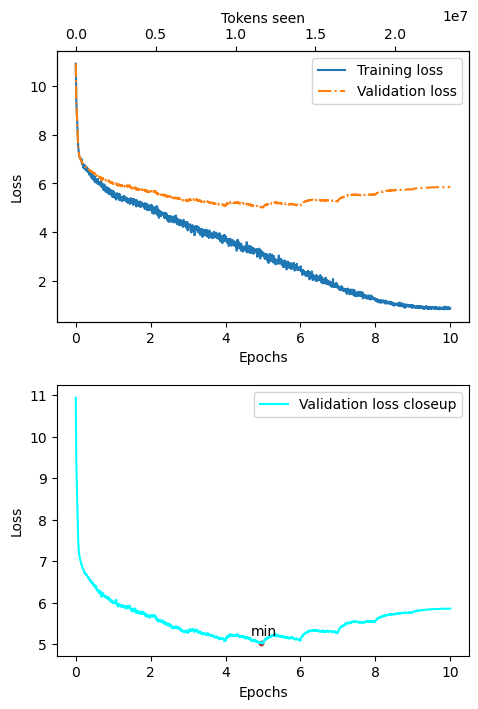

In [49]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import numpy as np

n_epochs=10
train_losses = train_results['train_losses']
epochs_tensor = torch.linspace(0, n_epochs, len(train_losses))
plot_losses(epochs_tensor, train_results['tokens_seen'], train_losses, train_results['val_losses'])

Model is overfitting to the training set past epoch 2 (training loss drops precipitously while validation loss remains more or less constant.

The second plot shows that the minimum validation loss is achieved on a batch during the 6th epoch, quite a while before training ends, meaning that from that point on validation scores were all worse.

The minimum validation loss:

In [122]:
import numpy as np
idx = np.array(val_losses).argmin()
(x,y) = epochs_tensor[idx], val_losses[idx]
x,y

(tensor(5.8824), 6.104353427886963)

##  From pretrained

This section departs from the script and just loads a lightweight versin of the saved GPT2 weights saved to the local machine.

#### path to saved weights (gpt2-small)

Weights downloaded and saved in  the `weight-loading-pytorch.ipynb` notebook.

In [11]:
BASE_CONFIG = {
    "vocab_size": 50257,    # Vocabulary size
    "context_length": 1024, # Context length
    "drop_rate": 0.0,       # Dropout rate
    "qkv_bias": True        # Query-key-value bias
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}


CHOOSE_MODEL = "gpt2-small (124M)"
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

In [12]:
import os.path

notebook_dir = '/Users/gawron/Desktop/src/sphinx/python_for_ss_extras/colab_notebooks/'
llms_from_scratch = 'transformers/HuggingFaceTransformers/raschke/LLMs-from-scratch/'
llms_from_scratch = os.path.join(notebook_dir, llms_from_scratch)
weights_dir = 'ch05/02_alternative_weight_loading'
weights_dir  = os.path.join(llms_from_scratch, weights_dir)
file_name = "gpt2-small-124M.pth"
file_name = os.path.join(weights_dir,file_name)

In [13]:
file_name

'/Users/gawron/Desktop/src/sphinx/python_for_ss_extras/colab_notebooks/transformers/HuggingFaceTransformers/raschke/LLMs-from-scratch/ch05/02_alternative_weight_loading/gpt2-small-124M.pth'

In [172]:
from accelerate import Accelerator
#from transformers import GPT2LMHeadModel, GPT2TokenizerFast

model = GPTModel(BASE_CONFIG)
model.load_state_dict(torch.load(file_name, weights_only=True))
model.eval()

device = Accelerator().device
model.to(device);

### Generation task

In [158]:
import tiktoken
from llms_from_scratch.ch05 import generate, text_to_token_ids, token_ids_to_text
import torch

torch.manual_seed(123)

tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate(
    model=model.to(device),
    idx=text_to_token_ids("Every effort moves", tokenizer).to(device),
    max_new_tokens=30,
    context_size=BASE_CONFIG["context_length"],
    top_k=1,
    temperature=1.0
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves forward, but it's not enough.

"I'm not going to sit here and say, 'I'm not going to do this,'


In [30]:
#tokenizer = GPT2TokenizerFast.from_pretrained(model_id,token=HF_TOKEN)

###  Perplexity computation task

### The dataset

Only do this the first time

In [159]:
from datasets import load_dataset

test = load_dataset("wikitext", "wikitext-2-raw-v1", split="test",token=HF_TOKEN)

In [60]:
from datasets import load_dataset

all_wiki = load_dataset("wikitext", "wikitext-2-raw-v1",token=HF_TOKEN)

Now save it locally.

In [61]:
all_wiki.save_to_disk("wikitext-2-raw-v1-all")

Saving the dataset (0/1 shards):   0%|          | 0/4358 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/36718 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/3760 [00:00<?, ? examples/s]

In [63]:
os.getcwd()

'/Users/gawron/Desktop/src/sphinx/python_for_ss_extras/colab_notebooks/transformers/HuggingFaceTransformers/raschke/LLMs-from-scratch'

Note where it is:

In [30]:
import os.path
os.getcwd()

'/Users/gawron/Desktop/src/sphinx/python_for_ss_extras/colab_notebooks/transformers/HuggingFaceTransformers/raschke/LLMs-from-scratch'

From now on load it from disk:

In [17]:
from accelerate import Accelerator
#from transformers import GPT2LMHeadModel, GPT2TokenizerFast
device = Accelerator().device

In [14]:
from datasets import load_from_disk
test = load_from_disk("wikitext-2-raw-v1")

Encode the wikitext data for processing by whichever model we use.

In [18]:
from transformers import AutoTokenizer
# This one doesnt work?
#tokenizer = tiktoken.get_encoding("gpt2")
# alternative tokenizer model "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained("gpt2")
#tokenizer = AutoTokenizer.from_pretrained( "bert-base-uncased")
encodings = tokenizer.encode("\n\n".join(test["text"]),return_tensors="pt").to(device)
#seq_len= len(encodings['input_ids'])

Token indices sequence length is longer than the specified maximum sequence length for this model (287644 > 1024). Running this sequence through the model will result in indexing errors


## The open AI model

The default weights loaded are those for the large GPT 2 model.

In [19]:
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
import os
HF_TOKEN = os.environ["HF_TOKEN"]
# perp = 
model_id = "openai-community/gpt2-large"
#model id for the smaller model perplexity goes from 19.44 to app. 30 on the wiki data
#model_id = "openai-community/gpt2"
model = GPT2LMHeadModel.from_pretrained(model_id,token=HF_TOKEN).to(device)

Loading weights:   0%|          | 0/436 [00:00<?, ?it/s]

In [20]:
import torch
from tqdm import tqdm

seq_len = encodings.shape[1]
stride,max_length=1024,1024
nll_sum = 0.0
n_tokens = 0
prev_end_loc = 0

for begin_loc in tqdm(range(0, seq_len, stride)):
    # To do 3 seqs of len 1024
    #for begin_loc in tqdm(range(0, 3072, stride)):
    end_loc = min(begin_loc + max_length, seq_len)
    trg_len = end_loc - prev_end_loc  # may be different from stride on last loop
    input_ids = encodings[:, begin_loc:end_loc].to(device)
    target_ids = input_ids.clone()
    target_ids[:, :-trg_len] = -100
    with torch.no_grad():     #1
        #logits = model(input_ids)
        outputs = model(input_ids, labels=target_ids)
        # loss is calculated using CrossEntropyLoss which averages over valid labels
        # N.B. the model only calculates loss over trg_len - 1 labels, because it internally shifts the labels
        # to the left by 1.
        neg_log_likelihood = outputs.loss
    #nll_sum -= compute_loss(logits,trg_len,target_ids)
    #nll_sum += compute_loss(logits,target_ids)
    num_valid_tokens = (target_ids != -100).sum().item()  # number of valid tokens in target_ids
    batch_size = target_ids.size(0)
    num_loss_tokens = num_valid_tokens - batch_size  # subtract batch_size 
    nll_sum += neg_log_likelihood * num_loss_tokens
    n_tokens += num_loss_tokens
    prev_end_loc = end_loc
    if end_loc == seq_len:
        break

avg_nll = nll_sum / n_tokens  # average negative log-likelihood per token
avg_nll
ppl = torch.exp(avg_nll)

100%|████████████████████████████████████████▊| 280/281 [03:51<00:00,  1.21it/s]


In [21]:
avg_nll

tensor(2.9671, device='mps:0')

In [22]:
ppl = torch.exp(avg_nll)
ppl

tensor(19.4360, device='mps:0')

In [92]:
n_tokens

286339

## Version 2 

Compute the perplexity for this dataset for this model

```
dataset wikitext-2-raw-v1
model GPTModel(BASE_CONFIG)
```

This version must use a  `GPTModel(GPT_CONFIG_124M)` instance; `GPT2LMHeadModel.from_pretrained(("openai-community/gpt2-large")` instances don't work.

The perplexity on the Wiki data is almost exactly the samae as the above
small GPT2 model, 29.66.

In [96]:
from accelerate import Accelerator

file_name = "gpt2-small-124M.pth"
file_name = os.path.join(weights_dir,file_name)
model = GPTModel(BASE_CONFIG)
model.load_state_dict(torch.load(file_name, weights_only=True))
model.eval()

device = Accelerator().device
model.to(device);

In [81]:
import torch
from tqdm import tqdm

seq_len = encodings.shape[1]
stride,max_length=1024,1024
nll_sum = 0.0
n_tokens = 0
prev_end_loc = 0
#m = nn.LogSoftmax(dim=1)
#loss_fn = nn.NLLLoss(reduction="sum")
#loss_fn = nn.NLLLoss()
#target = torch.tensor([1, 0, 4])
#output = loss_fn(m(logits), target)
#calc_loss_batch(input_batch, target_batch, model, device)

def compute_loss(input_batch,target_batch, model):
    #print(input_batch.shape)
    #print(target_batch.shape)
    return calc_loss_batch(input_batch, target_batch, model, device)

def compute_loss_old(logits,target_ids):
    """
    dimensionality issue:  get get this to work with a batch dimension
    at all.  Dimensionality mismatch complaints. 
    
    This seems to work but gets
    """
    #print(logits.shape)
    log_probas = m(logits)
    print(log_probas[0].shape)
    print(target_ids[0].shape)
    #print(loss_vec.shape)
    output = loss_fn(log_probas[0], target_ids[0])
    #print(output)
    return output#.sum()

In [82]:
seq_len = encodings.shape[1]
stride,max_length=1024,1024
nll_sum = 0.0
n_tokens = 0
prev_end_loc = 0

for begin_loc in tqdm(range(0, seq_len, stride)):
    #for begin_loc in tqdm(range(0, 3072, stride)):
    end_loc = min(begin_loc + max_length, seq_len)
    trg_len = end_loc - prev_end_loc  # may be different from stride on last loop
    input_ids = encodings[:, begin_loc:end_loc].to(device)
    target_ids = encodings[:, begin_loc+1:end_loc+1].to(device)
    if input_ids.shape[1] != target_ids.shape[1]:
        print(f"Skipping {begin_loc}-{end_loc}")
        continue
    #target_ids = input_ids.clone()
    target_ids[:, :-trg_len] = -100
    #if len(target_ids[:, :-trg_len]) > 20:
    #    print(len(target_ids[:, :-trg_len]))
    #print(input_ids.shape)
    with torch.no_grad():     #1
        neg_log_likelihood = compute_loss(input_ids,target_ids, model)
        #logits = model(input_ids)
        #outputs = model(input_ids, labels=target_ids)
        # loss is calculated using CrossEntropyLoss which averages over valid labels
        # N.B. the model only calculates loss over trg_len - 1 labels, because it internally shifts the labels
        # to the left by 1.
        #neg_log_likelihood = outputs.loss
    #nll_sum += compute_loss(logits,target_ids)
    #num_valid_tokens = (target_ids != -100).sum().item()  # number of valid tokens in target_ids
    num_valid_tokens=input_ids.shape[1]
    #batch_size = target_ids.size(0)
    batch_size=0
    num_loss_tokens = num_valid_tokens - batch_size  # subtract batch_size 
    nll_sum += neg_log_likelihood * num_loss_tokens
    n_tokens += num_loss_tokens
    prev_end_loc = end_loc
    if end_loc == seq_len:
        break

avg_nll = nll_sum / n_tokens  # average negative log-likelihood per token
#avg_nll
#ppl = torch.exp(avg_nll)

100%|█████████████████████████████████████████| 281/281 [00:41<00:00,  6.76it/s]

Skipping 286720-287644


In [84]:
ppl = torch.exp(avg_nll)
ppl

tensor(29.6562, device='mps:0')

In [85]:
avg_nll

tensor(3.3897, device='mps:0')

## Generation revisited

In [23]:
model

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 1280)
    (wpe): Embedding(1024, 1280)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-35): 36 x GPT2Block(
        (ln_1): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=3840, nx=1280)
          (c_proj): Conv1D(nf=1280, nx=1280)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=5120, nx=1280)
          (c_proj): Conv1D(nf=1280, nx=5120)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=1280, out_features=50257, bias=False)
)

This generator function requires one of the pretrained GPT models (it assumes
a lot of internal features the models trained in the book chapters (e.g., GPT

In [40]:
from transformers import pipeline, set_seed
generator = pipeline('text-generation', model=model,tokenizer=tokenizer)
#generator = pipeline('text-generation', model='gpt2')
#set_seed(42)

def run_generator(generator,prompt,max_length=30,num_return_sequences=5,
                  verbose=False,seed=None):
    if seed is not None:
        set_seed(seed)
    texts = generator(prompt, max_length=max_length, 
                      num_return_sequences=num_return_sequences)
    if verbose:
        for (i,txt) in enumerate(texts):
            print(f"Text {i+1}:\n======")
            print(txt["generated_text"])

In [41]:
texts = run_generator(generator,"Hello, I'm a language model,",
                      verbose=True,seed=42)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=30) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Text 1:
Hello, I'm a language model, and my project is a language model. It's an object-oriented programming language, so I can program in it. It's written in Java, so I can use it in my Java-based application.

But I don't want to use it in my application because it's not object-oriented. So I want to write in this language, and I want to use it in my application. So I'm going to create a data model. And I've written about data models before, but I'm going to write about this one more time, because it's so important.

So, let's say I have a data model like this:

data Person = Person { firstName :: String, lastName :: String, age :: Int }

I need to be able to get this Person and to put it into a database table.

So, I will create a data model in my project, and I'll use that data model to get the Person from my database. And I'll use that Person to create a model that I can then put into my application.

And I'll write a class that is called Person, and I'll name it PersonModel.

And

In [39]:
texts2 = run_generator(generator,"or some great Shakespearean tragedy,",
                       verbose=True,seed=43)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=30) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Text 1:
or some great Shakespearean tragedy, or a great war drama. It's also a way to make your own choices. As a reader, you can decide whether to read a book about a man who kills a man, or a book about a woman who has a child with a man, or a book about a man who has to kill a man.

The point is not that you have an obligation to read about men who kill men. The point is that you can decide on your own, without the help of others, whether to read a book about the killing of men, or a book about the killing of women.

The point is not that you have an obligation to read about men who kill men. The point is that you can decide on your own, without the help of others, whether to read a book about the killing of men, or a book about the killing of women.

This is not an argument that we need to replace the Bible with something better. This is an argument that the Bible, far from being an all-encompassing or universal morality, needs to be read in its particular setting and context, and 

### From datasets  tutorial

In [36]:
from datasets import load_dataset_builder,get_dataset_split_names
ds_builder = load_dataset_builder("cornell-movie-review-data/rotten_tomatoes")

In [34]:
# Inspect dataset description
ds_builder.info.description

''

Movie Review Dataset. 
This is a dataset of containing 5,331 positive and 5,331 negative processed sentences from Rotten Tomatoes movie reviews. This data was first used in Bo Pang and Lillian Lee, ``Seeing stars: Exploiting class relationships for sentiment categorization with respect to rating scales.'', Proceedings of the ACL, 2005.

In [35]:
# Inspect dataset features
ds_builder.info.features
#{'label': ClassLabel(names=['neg', 'pos']),
# 'text': Value('string')}

{'text': Value('string'), 'label': ClassLabel(names=['neg', 'pos'])}

In [42]:
get_dataset_split_names("cornell-movie-review-data/rotten_tomatoes")

['train', 'validation', 'test']

Load the actual data:

In [ ]:
dataset = load_dataset("cornell-movie-review-data/rotten_tomatoes", split="train")